# **Intensitat de les Pluges — Sabadell Nord vs Vacarisses**

Anàlisi de la intensitat de pluges a partir de dades de 30 minuts.

**Estacions:** Sabadell Nord (30 min, 2008–2026), Vacarisses (30 min, 1996–2026)

**Contingut:**
1. Càrrega de dades
2. Histograma d'intervals de 30 minuts (Sbd Nord)
3. Scatter: intensitat vs temps normalitzat (Sbd Nord)
4. Barres: nombre de períodes de pluja per any (Sbd Nord + Vacarisses)
5. Pluja específica: mitjana anual (punt per any)
6. Màxima intensitat per any (daily / 30 min / hourly)

## 1. Càrrega de Dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# === SABADELL NORD (30 min) ===
url_nord = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_hourly.csv'
df_nord = pd.read_csv(url_nord)
df_nord['datetime_utc'] = pd.to_datetime(df_nord['datetime_utc'], errors='coerce')
df_nord = df_nord.dropna(subset=['datetime_utc'])
df_nord['year'] = df_nord['datetime_utc'].dt.year
df_nord['month'] = df_nord['datetime_utc'].dt.month
df_nord['hour'] = df_nord['datetime_utc'].dt.hour
df_nord = df_nord.sort_values('datetime_utc').reset_index(drop=True)

# === VACARISSES (30 min) ===
url_vac = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Vacarisses_hourly.csv'
df_vac = pd.read_csv(url_vac)
df_vac['datetime_utc'] = pd.to_datetime(df_vac['datetime_utc'], errors='coerce')
df_vac = df_vac.dropna(subset=['datetime_utc'])
df_vac['year'] = df_vac['datetime_utc'].dt.year
df_vac['month'] = df_vac['datetime_utc'].dt.month
df_vac['hour'] = df_vac['datetime_utc'].dt.hour
df_vac = df_vac.sort_values('datetime_utc').reset_index(drop=True)

print(f'Sbd Nord:  {len(df_nord):,} registres | {df_nord["datetime_utc"].min().date()} → {df_nord["datetime_utc"].max().date()}')
print(f'Vacarisses: {len(df_vac):,} registres | {df_vac["datetime_utc"].min().date()} → {df_vac["datetime_utc"].max().date()}')

Sbd Nord:  305,664 registres | 2008-10-24 → 2026-04-01
Vacarisses: 525,936 registres | 1996-02-16 → 2026-04-01


## 2. Histograma d'Intervals de 30 minuts (Sbd Nord)

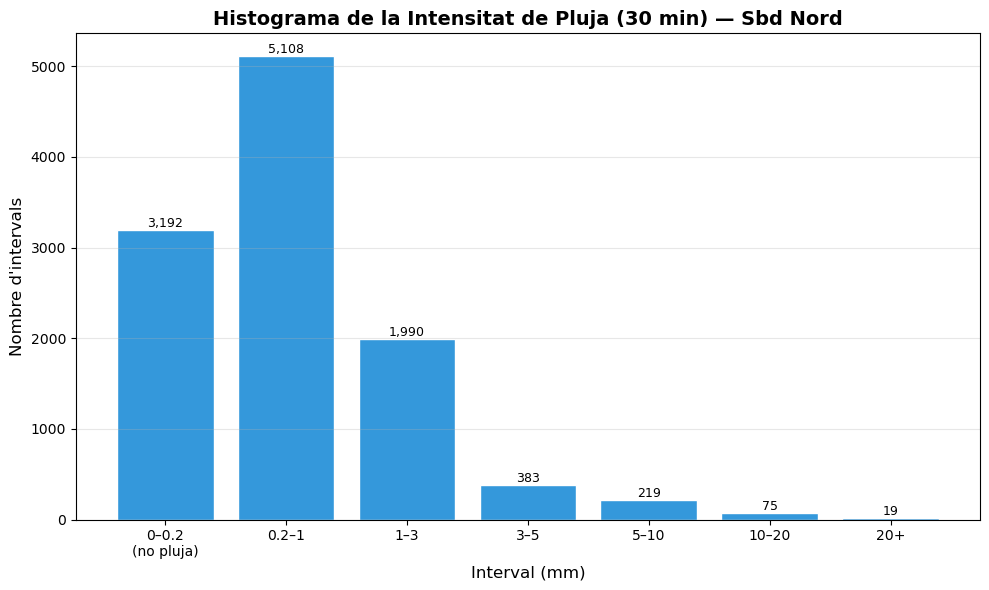

                   Recompte  Percentatge (%)
Interval (mm)                               
0–0.2\n(no pluja)      3192             29.1
0.2–1                  5108             46.5
1–3                    1990             18.1
3–5                     383              3.5
5–10                    219              2.0
10–20                    75              0.7
20+                      19              0.2


In [4]:
# Rang d'intervals
bins = [0, 0.2, 1, 3, 5, 10, 20, np.inf]
labels = ['0–0.2\n(no pluja)', '0.2–1', '1–3', '3–5', '5–10', '10–20', '20+']

nord_rain = df_nord[df_nord['rain_mm'] > 0].copy()
nord_rain['bin'] = pd.cut(nord_rain['rain_mm'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(10, 6))
counts = nord_rain['bin'].value_counts().reindex(labels)
bars = ax.bar(range(len(counts)), counts.values, color='#3498db', edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_xlabel('Interval (mm)', fontsize=12)
ax.set_ylabel('Nombre d\'intervals', fontsize=12)
ax.set_title('Histograma de la Intensitat de Pluja (30 min) — Sbd Nord', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Etiquetes amb nombre exacte
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
           f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Taula amb percentatges
total = len(nord_rain)
pct = counts / total * 100
tbl = pd.DataFrame({'Recompte': counts.values, 'Percentatge (%)': pct.values.round(1)}, index=labels)
tbl.index.name = 'Interval (mm)'
print(tbl)

## 3. Scatter — Intensitat vs Temps Normalitzat (Sbd Nord)

Temps normalitzat: t = 0 en la primera lectura. Cada unitat = 1 hora.
Intervals consecutius dins la mateixa hora se sumen.

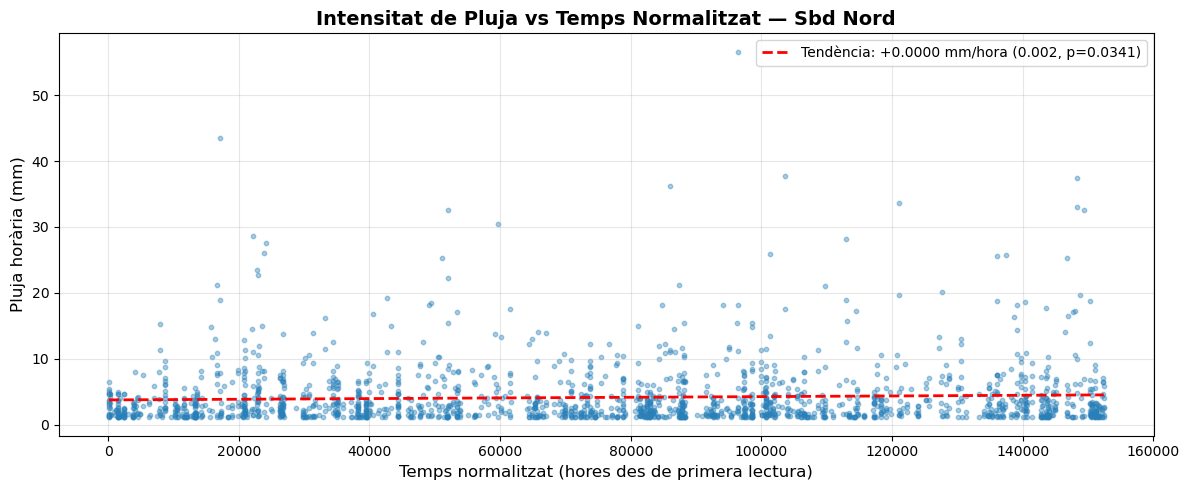

Punts totals: 1799
Tendència: +0.0000 mm/hora per hora transcorreguda


In [6]:
# Filtrar: només lectures amb pluja (> 0.2 mm)
df_sc = df_nord[df_nord['rain_mm'] > 1].copy()

# Hora d'inici (pivot per agrupar)
df_sc['hour_start'] = df_sc['datetime_utc'].dt.floor('H')

# Sumar tots els intervals de 30 min dins cada hora
hourly_agg = df_sc.groupby('hour_start')['rain_mm'].sum().reset_index()
hourly_agg.columns = ['hour_start', 'rain_mm']

# Temps normalitzat en hores des de la primera lectura
t0 = df_nord['datetime_utc'].min()
hourly_agg['t'] = (hourly_agg['hour_start'] - t0).dt.total_seconds() / 3600
hourly_agg = hourly_agg.sort_values('t')

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(hourly_agg['t'], hourly_agg['rain_mm'], alpha=0.4, s=10, color='#2980b9')
ax.set_xlabel('Temps normalitzat (hores des de primera lectura)', fontsize=12)
ax.set_ylabel('Pluja horària (mm)', fontsize=12)
ax.set_title('Intensitat de Pluja vs Temps Normalitzat — Sbd Nord', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Tendència lineal
slope, intercept, r_val, p_val, _ = stats.linregress(hourly_agg['t'], hourly_agg['rain_mm'])
x_line = np.array([hourly_agg['t'].min(), hourly_agg['t'].max()])
ax.plot(x_line, intercept + slope * x_line, color='red', linewidth=2, linestyle='--',
        label=f'Tendència: {slope:+.4f} mm/hora ({r_val**2:.3f}, p={p_val:.4f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Punts totals: {len(hourly_agg)}')
print(f'Tendència: {slope:+.4f} mm/hora per hora transcorreguda')

## 4. Nombre de Períodes de Pluja per Any

Un període de pluja = sèrie consecutiva d'intervals de 30 min amb pluja > 0.2 mm.

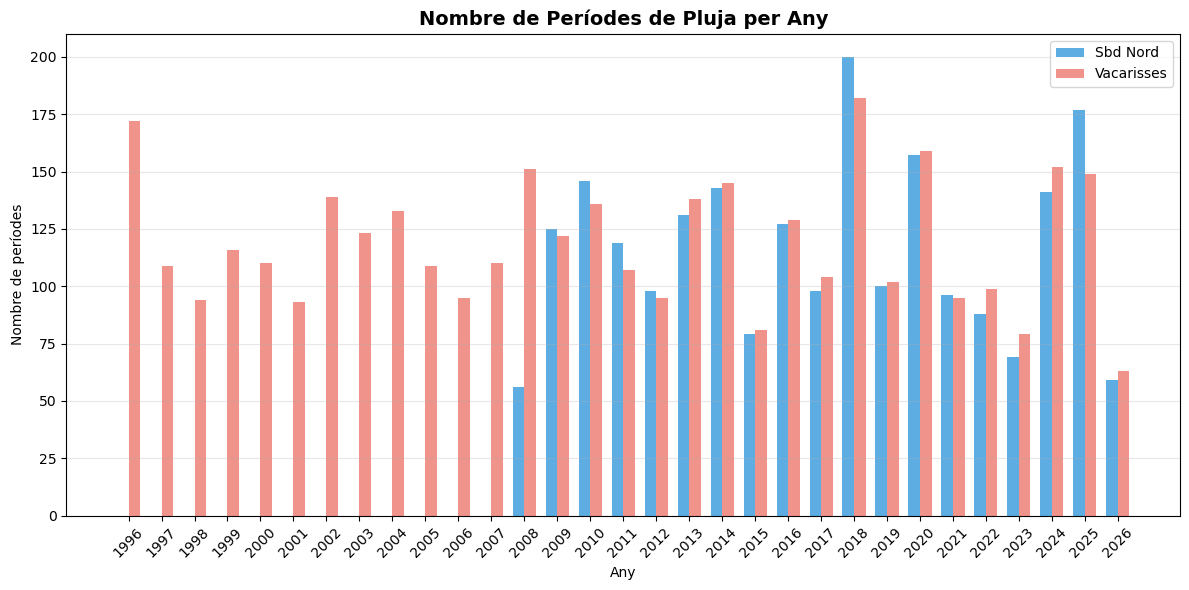

Sbd Nord:  2209 períodes totals
Vacarisses: 3691 períodes totals


In [8]:
def count_rain_periods(df, station_name):
    """Compta el nombre de períodes de pluja per any."""
    df_s = df[df['rain_mm'] > 0.2].copy()
    df_s = df_s.sort_values('datetime_utc').reset_index(drop=True)
    
    results = []
    for year, group in df_s.groupby('year'):
        group = group.sort_values('datetime_utc')
        in_period = False
        count = 0
        prev_ts = None
        for ts in group['datetime_utc']:
            if not in_period:
                in_period = True
                count += 1
                prev_ts = ts
            else:
                # Si hi ha un salt > 30 min, comença un nou període
                if (ts - prev_ts).total_seconds() > 30 * 60:
                    count += 1
                prev_ts = ts
        results.append({'year': year, 'periods': count})
    return pd.DataFrame(results)

periods_nord_s = periods_nord.set_index('year')['periods']
periods_vac_s = periods_vac.set_index('year')['periods']

nord_values = periods_nord_s.reindex(all_years, fill_value=0)
vac_values = periods_vac_s.reindex(all_years, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.35
x = np.arange(len(all_years))

ax.bar(x - width/2, nord_values, width, label='Sbd Nord',
       color='#3498db', alpha=0.8)

ax.bar(x + width/2, vac_values, width, label='Vacarisses',
       color='#e74c3c', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in all_years], rotation=45)
ax.set_xlabel('Any')
ax.set_ylabel('Nombre de períodes')
ax.set_title('Nombre de Períodes de Pluja per Any', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f'Sbd Nord:  {periods_nord["periods"].sum()} períodes totals')
print(f'Vacarisses: {periods_vac["periods"].sum()} períodes totals')

## 5. Pluja Específica — Mitjana Anual

Pluja específica = (rain_mm / hores) × 100
Només hores amb almenys 1 interval de 30 min amb pluja > 0.2 mm.
Per a Vacarisses (diari), la intensitat horària és diària / 24.

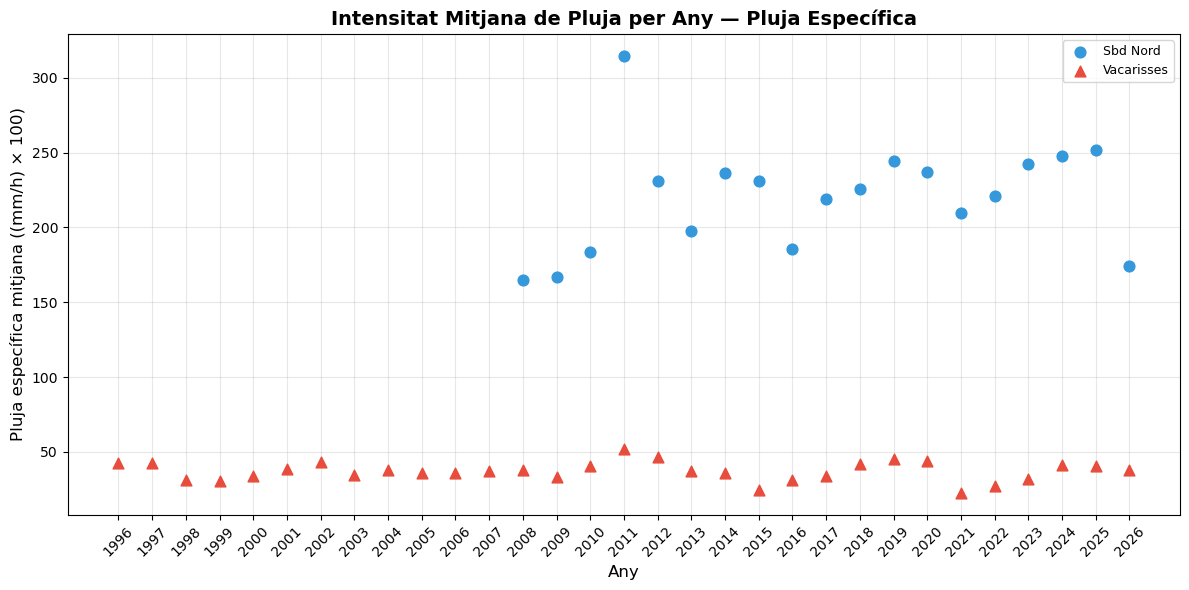

In [12]:
# === SBD NORD: pluja específica horària ===
df_n = df_nord[df_nord['rain_mm'] > 0.2].copy()
df_n['hour_start'] = df_n['datetime_utc'].dt.floor('H')
hourly_n = df_n.groupby(['year', 'hour_start'])['rain_mm'].sum().reset_index()
hourly_n['specific_rain'] = (hourly_n['rain_mm'] / 1) * 100  # 1 hora

spec_nord = hourly_n.groupby('year')['specific_rain'].mean().reset_index()
spec_nord.columns = ['year', 'specific_rain']

DATA_DIR = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/'

# === VACARISSES: carregar diari i fer intensitat horària ===
df_vac_d = pd.read_csv(DATA_DIR + 'Vacarisses_daily.csv')
df_vac_d['date'] = pd.to_datetime(df_vac_d['date'])
df_vac_d['year'] = df_vac_d['date'].dt.year
df_vac_d = df_vac_d[df_vac_d['rain_mm'] > 0.2]
df_vac_d['specific_rain'] = (df_vac_d['rain_mm'] / 24) * 100
spec_vac = df_vac_d.groupby('year')['specific_rain'].mean().reset_index()
spec_vac.columns = ['year', 'specific_rain']

all_years_spec = sorted(set(spec_nord['year']) | set(spec_vac['year']))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_years_spec))
ax.scatter(all_years_spec,
           [spec_nord.set_index('year').loc[y, 'specific_rain'] if y in spec_nord['year'].values else np.nan for y in all_years_spec],
           label='Sbd Nord', color='#3498db', s=60, zorder=3)
ax.scatter(all_years_spec,
           [spec_vac.set_index('year').loc[y, 'specific_rain'] if y in spec_vac['year'].values else np.nan for y in all_years_spec],
           label='Vacarisses', color='#e74c3c', s=60, marker='^', zorder=3)



ax.set_xlabel('Any', fontsize=12)
ax.set_ylabel('Pluja específica mitjana ((mm/h) × 100)', fontsize=12)
ax.set_title('Intensitat Mitjana de Pluja per Any — Pluja Específica', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(all_years_spec)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Màxima Intensitat per Any

**Sbd Nord:** màxima diària, màxima horària (suma d'intervals de 30 min dins l'hora), màxima 30-min.
**Vacarisses:** màxima diària.
**Sbd Centre:** màxima diària.

In [13]:
# === SBD NORD: màxima 30-min per any ===
max30_nord = df_nord[df_nord['rain_mm'] > 0].groupby('year')['rain_mm'].max().reset_index()
max30_nord.columns = ['year', 'max_30min']

# === SBD NORD: màxima horària (suma d'intervals dins cada hora) ===
df_nord['hour_start'] = df_nord['datetime_utc'].dt.floor('H')
hourly_nord = df_nord.groupby(['year', 'hour_start'])['rain_mm'].sum().reset_index()
max_h_nord = hourly_nord.groupby('year')['rain_mm'].max().reset_index()
max_h_nord.columns = ['year', 'max_hourly']

# === SBD NORD: màxima diària ===
df_nord['date'] = df_nord['datetime_utc'].dt.normalize()
daily_nord = df_nord.groupby(['year', 'date'])['rain_mm'].sum().reset_index()
max_d_nord = daily_nord.groupby('year')['rain_mm'].max().reset_index()
max_d_nord.columns = ['year', 'max_daily']

# === VACARISSES: màxima diària ===
df_vac_d = pd.read_csv(DATA_DIR + 'Vacarisses_daily.csv')
df_vac_d['date'] = pd.to_datetime(df_vac_d['date'])
df_vac_d['year'] = df_vac_d['date'].dt.year
max_d_vac = df_vac_d.groupby('year')['rain_mm'].max().reset_index()
max_d_vac.columns = ['year', 'max_daily_vac']

# === SBD CENTRE: màxima diària ===
df_c_d = pd.read_csv(DATA_DIR + 'Sbd_Centre_daily.csv')
df_c_d['date'] = pd.to_datetime(df_c_d['date'])
df_c_d['year'] = df_c_d['date'].dt.year
max_d_c = df_c_d.groupby('year')['rain_mm'].max().reset_index()
max_d_c.columns = ['year', 'max_daily_centre']

# Merge
max_df = max_d_nord.merge(max_h_nord, on='year', how='outer')
max_df = max_df.merge(max30_nord, on='year', how='outer')
max_df = max_df.merge(max_d_vac, on='year', how='outer')
max_df = max_df.merge(max_d_c, on='year', how='outer')
max_df = max_df.sort_values('year').reset_index(drop=True)

print('Màxima intensitat per any (mm):')
print(max_df.to_string(index=False))

Màxima intensitat per any (mm):
 year  max_daily  max_hourly  max_30min  max_daily_vac  max_daily_centre
 1996        NaN         NaN        NaN           83.0               NaN
 1997        NaN         NaN        NaN          136.8               NaN
 1998        NaN         NaN        NaN           76.4               NaN
 1999        NaN         NaN        NaN           57.4               NaN
 2000        NaN         NaN        NaN           75.6               NaN
 2001        NaN         NaN        NaN           39.4               NaN
 2002        NaN         NaN        NaN          120.4               NaN
 2003        NaN         NaN        NaN           45.6               NaN
 2004        NaN         NaN        NaN           46.6               NaN
 2005        NaN         NaN        NaN           50.6               NaN
 2006        NaN         NaN        NaN          124.4               NaN
 2007        NaN         NaN        NaN           53.6               NaN
 2008       34.3   

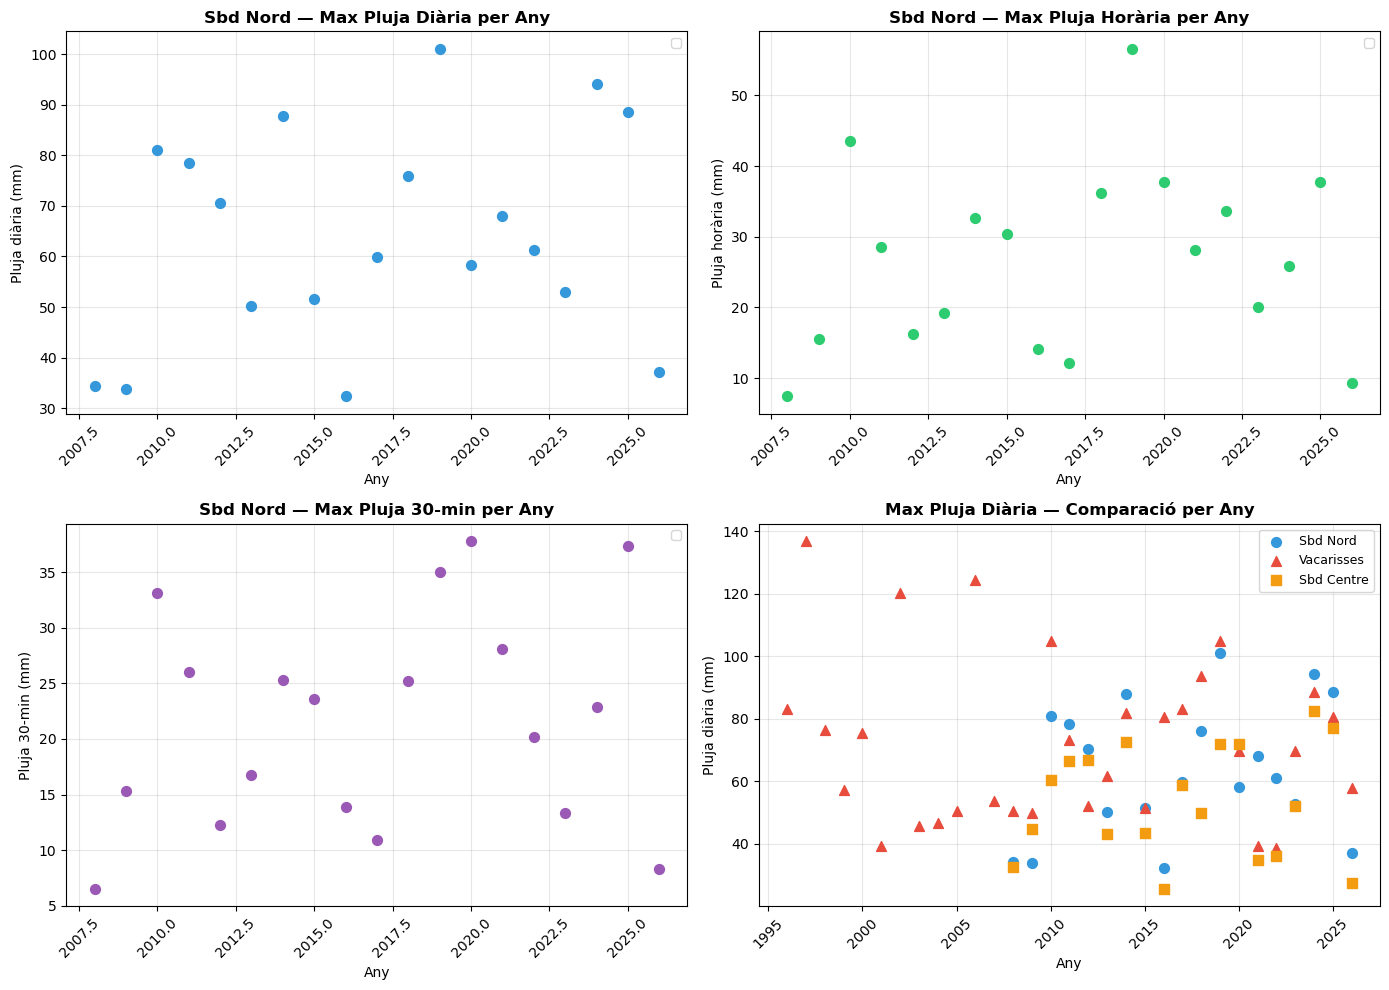

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Max diària Sbd Nord
ax = axes[0, 0]
ax.scatter(max_df['year'], max_df['max_daily'], color='#3498db', s=50, zorder=3)
valid = max_df[['year', 'max_daily']].dropna()
ax.set_title('Sbd Nord — Max Pluja Diària per Any', fontsize=12, fontweight='bold')
ax.set_xlabel('Any')
ax.set_ylabel('Pluja diària (mm)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Max horària Sbd Nord
ax = axes[0, 1]
ax.scatter(max_df['year'], max_df['max_hourly'], color='#2ecc71', s=50, zorder=3)
valid = max_df[['year', 'max_hourly']].dropna()
ax.set_title('Sbd Nord — Max Pluja Horària per Any', fontsize=12, fontweight='bold')
ax.set_xlabel('Any')
ax.set_ylabel('Pluja horària (mm)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Max 30-min Sbd Nord
ax = axes[1, 0]
ax.scatter(max_df['year'], max_df['max_30min'], color='#9b59b6', s=50, zorder=3)
valid = max_df[['year', 'max_30min']].dropna()

ax.set_title('Sbd Nord — Max Pluja 30-min per Any', fontsize=12, fontweight='bold')
ax.set_xlabel('Any')
ax.set_ylabel('Pluja 30-min (mm)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Max diària comparació: Sbd Nord + Vacarisses + Sbd Centre
ax = axes[1, 1]
years_all = sorted(set(max_df['year']))
x_pos = np.arange(len(years_all))
nord_vals = [max_df[max_df['year'] == y]['max_daily'].values[0] if y in max_df['year'].values else np.nan for y in years_all]
vac_vals  = [max_df[max_df['year'] == y]['max_daily_vac'].values[0] if y in max_df['year'].values else np.nan for y in years_all]
c_vals    = [max_df[max_df['year'] == y]['max_daily_centre'].values[0] if y in max_df['year'].values else np.nan for y in years_all]
ax.scatter(years_all, nord_vals, color='#3498db', s=50, label='Sbd Nord', zorder=3)
ax.scatter(years_all, vac_vals,  color='#e74c3c', s=50, marker='^', label='Vacarisses', zorder=3)
ax.scatter(years_all, c_vals,    color='#f39c12', s=50, marker='s', label='Sbd Centre', zorder=3)
ax.set_title('Max Pluja Diària — Comparació per Any', fontsize=12, fontweight='bold')
ax.set_xlabel('Any')
ax.set_ylabel('Pluja diària (mm)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()